In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import *
from imblearn.metrics import specificity_score
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyRegressor, LazyClassifier
from scipy.stats import randint, uniform, zscore, stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error, accuracy_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import TargetEncoder
from sklearn import linear_model
from sklearn.linear_model import Lasso, LogisticRegression, LinearRegression
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.compose import ColumnTransformer
import joblib

In [2]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')
pd.set_option('display.max_columns',None)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0 33.60   
1              1       85             66             29        0 26.60   
2              8      183             64              0        0 23.30   
3              1       89             66             23       94 28.10   
4              0      137             40             35      168 43.10   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180 32.90   
764            2      122             70             27        0 36.80   
765            5      121             72             23      112 26.20   
766            1      126             60              0        0 30.10   
767            1       93             70             31        0 30.40   

     DiabetesPedigreeFunction  Age  Outcome  
0                        0.63  

In [6]:
#revision valores unicos
uniques = df.nunique()
uniques

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [7]:
#filas dup

df.duplicated().sum()

np.int64(0)

In [8]:
#valores faltantes

faltantes = df.isna().mean()*100
faltantes


Pregnancies                0.00
Glucose                    0.00
BloodPressure              0.00
SkinThickness              0.00
Insulin                    0.00
BMI                        0.00
DiabetesPedigreeFunction   0.00
Age                        0.00
Outcome                    0.00
dtype: float64

In [9]:
#busqueda de valores faltantes "enmascarados" == 0 

ceros = df == 0 
perc_ceros = ceros.mean()*100
print(perc_ceros)

Pregnancies                14.45
Glucose                     0.65
BloodPressure               4.56
SkinThickness              29.56
Insulin                    48.70
BMI                         1.43
DiabetesPedigreeFunction    0.00
Age                         0.00
Outcome                    65.10
dtype: float64


In [10]:
#identificar variables donde el 0 no es aceptable (significando valor faltante)

var_cero = ['Glucose','BloodPressure','BMI','Insulin']

df[var_cero] == 0


,Glucose,BloodPressure,BMI,Insulin
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
763,False,False,False,False
764,False,False,False,True
765,False,False,False,False
766,False,False,False,True


In [11]:
#reemplazar 0s con NaNs
df[var_cero] = df[var_cero].replace(0,np.nan)

In [12]:
df.isna().mean()*100

Pregnancies                 0.00
Glucose                     0.65
BloodPressure               4.56
SkinThickness               0.00
Insulin                    48.70
BMI                         1.43
DiabetesPedigreeFunction    0.00
Age                         0.00
Outcome                     0.00
dtype: float64

<Axes: >

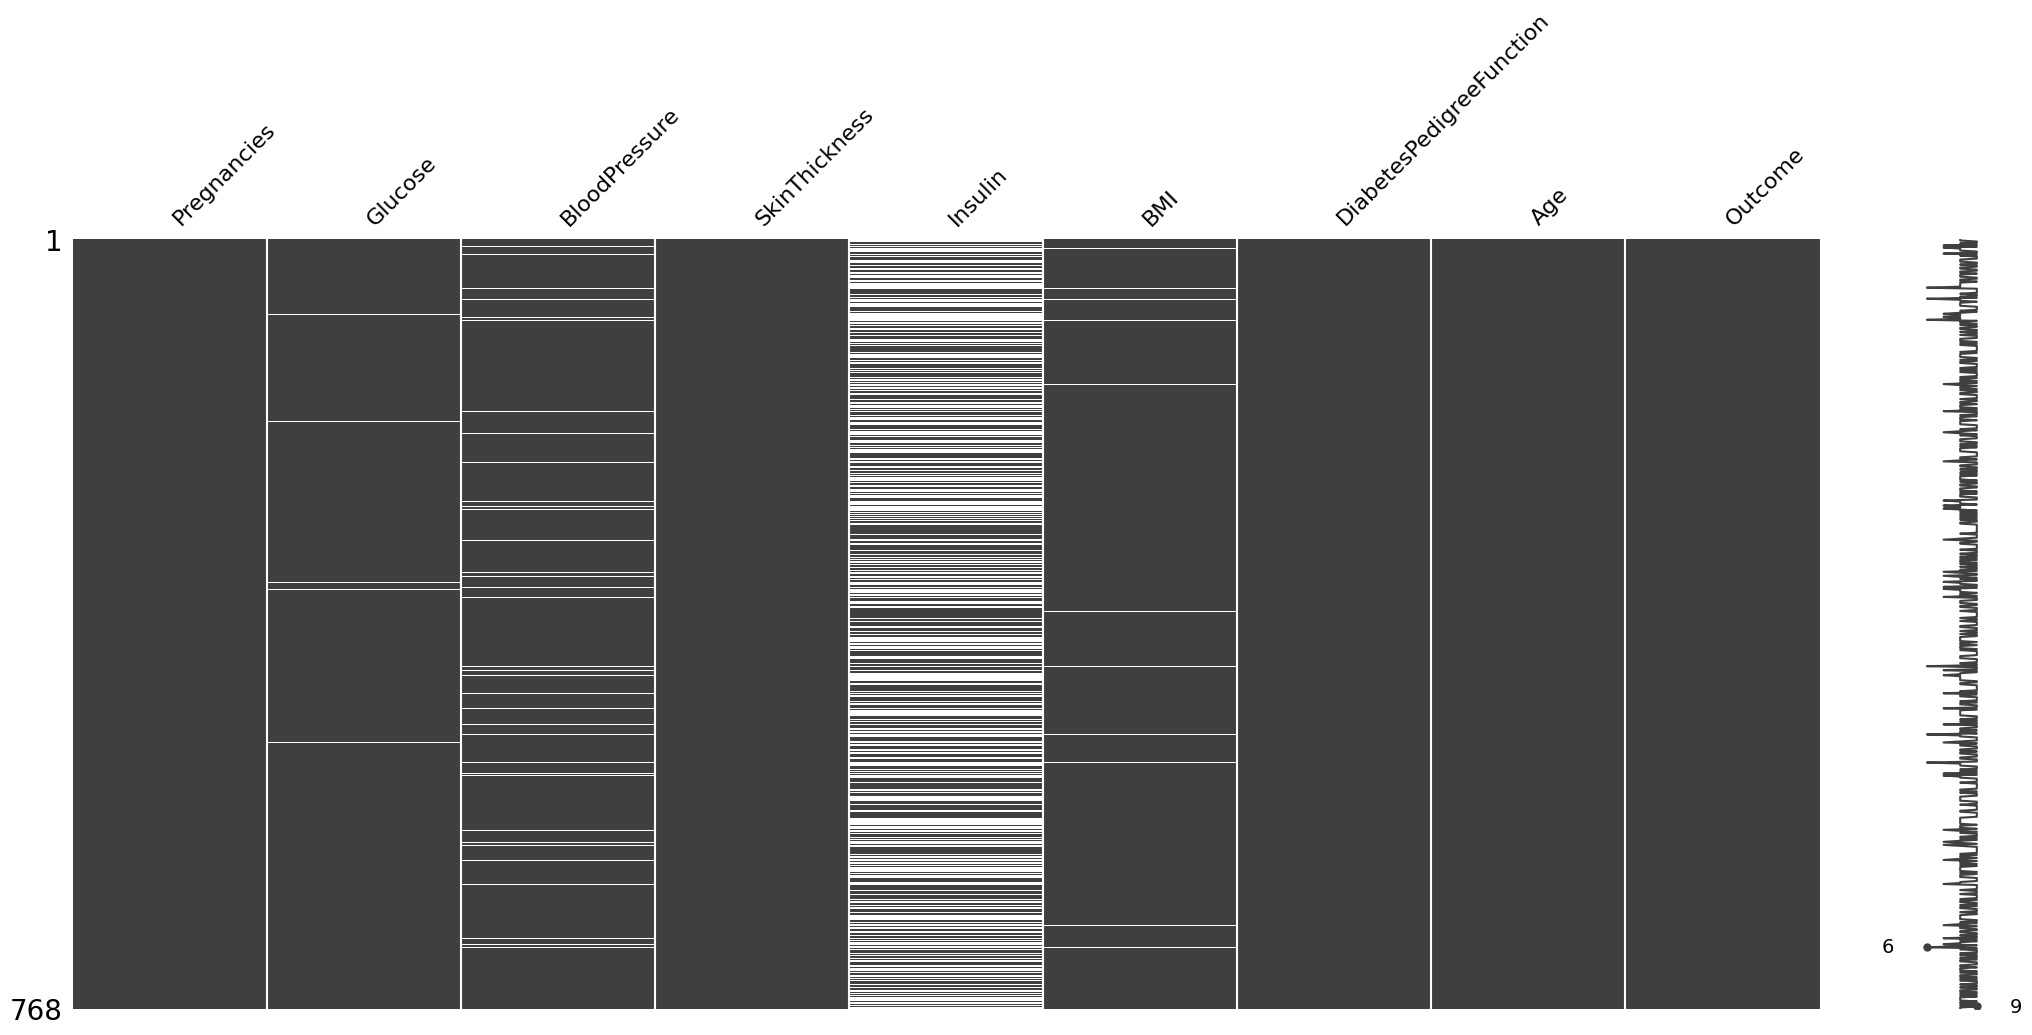

In [13]:
msno.matrix(df)

In [14]:
mask = df['Insulin'].isna()
df_nulos = df[mask]
df_nulos

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.00,72.00,35,NaN,33.60,0.63,50,1
1,1,85.00,66.00,29,NaN,26.60,0.35,31,0
2,8,183.00,64.00,0,NaN,23.30,0.67,32,1
5,5,116.00,74.00,0,NaN,25.60,0.20,30,0
7,10,115.00,NaN,0,NaN,35.30,0.13,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170.00,74.00,31,NaN,44.00,0.40,43,1
762,9,89.00,62.00,0,NaN,22.50,0.14,33,0
764,2,122.00,70.00,27,NaN,36.80,0.34,27,0
766,1,126.00,60.00,0,NaN,30.10,0.35,47,1


Columnas redudantes & Data leakage: no hay. El conjunto de datos que tenemos tiene solo 9 variables que parecen ser importantes al momento de predecir diabetes. 

In [15]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

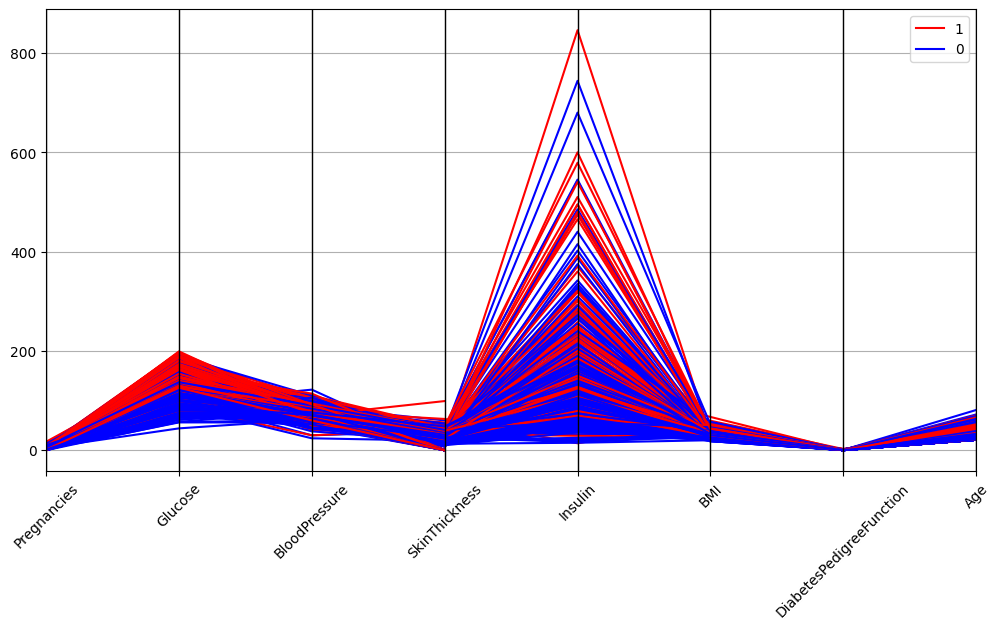

In [16]:
#visualizar relacion entre caract del dataset
plt.figure(figsize=(12, 6))
pd.plotting.parallel_coordinates(df, 'Outcome', color=['red', 'blue'])
plt.xticks(rotation=45)
plt.show()

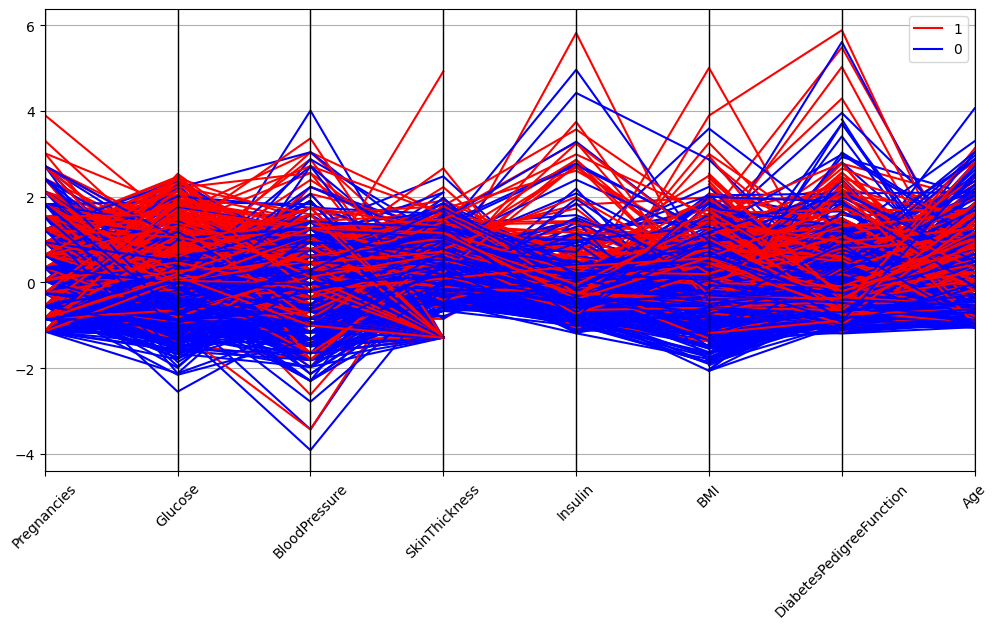

In [17]:
#Version escalada
df_sc = pd.DataFrame(data=StandardScaler().fit_transform(df.drop(['Outcome'], axis=1)), columns=df.columns[:-1])
df_sc['Outcome'] = df.Outcome


# Visualizamos la relación entre las características de nuestro dataset
plt.figure(figsize=(12, 6))
pd.plotting.parallel_coordinates(df_sc, 'Outcome', color=['red', 'blue'])
plt.xticks(rotation=45)
plt.show()

Al escalar los valores y volverlos a visualizar, podemos obervar que hay variables que podrían ser más o menos predictivas. Aquellas características en las que vemos mas homogenidad , es porque son debilmente discriminatorias o poco predictivas. Contrario a lo que pasa con aquellas donde vemos una mayor heterogenidad (pregnancies, glucose, Insulina, BMI) que muestran tener mayor relación con un diagnóstico positivo de diabetes. 

Train Test Split

In [18]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Imputación

In [20]:
# imputer = MissForest(numerical=['Glucose','BloodPressure','Insulin','BMI'])
# X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

In [21]:
imputer = MissForest()

X_train_imp = imputer.fit_transform(X_train)
X_train_imp

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 70.99it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
60,2,0,0.30,21,84.00,28.24,69.85,111.18
618,9,24,1.28,50,112.00,28.20,82.00,169.58
346,1,19,0.65,22,139.00,28.70,46.00,83.00
294,0,0,0.25,65,161.00,21.90,50.00,240.72
231,6,37,0.24,46,134.00,46.20,80.00,370.00
...,...,...,...,...,...,...,...,...
71,5,35,0.41,26,139.00,28.60,64.00,140.00
106,1,0,0.21,27,96.00,22.40,122.00,98.70
270,10,37,1.14,38,101.00,45.60,86.00,119.07
435,0,0,0.20,29,141.00,42.40,73.71,117.73


In [22]:
print(X_train_imp.isna().sum())

Pregnancies                 0
SkinThickness               0
DiabetesPedigreeFunction    0
Age                         0
Glucose                     0
BMI                         0
BloodPressure               0
Insulin                     0
dtype: int64


In [23]:
X_test_imp = imputer.transform(X_test)
X_test_imp

 60%|██████    | 3/5 [00:00<00:00, 75.20it/s]


,Pregnancies,SkinThickness,DiabetesPedigreeFunction,Age,Glucose,BMI,BloodPressure,Insulin
668,6,33,0.43,43,98.00,34.00,58.00,190.00
324,2,32,0.15,21,112.00,35.70,75.00,168.19
624,2,0,0.16,21,108.00,30.80,64.00,145.49
690,8,0,0.86,34,107.00,24.60,80.00,140.03
473,7,0,0.21,50,136.00,29.90,90.00,142.22
...,...,...,...,...,...,...,...,...
355,9,0,0.30,49,165.00,30.40,88.00,116.72
534,1,30,1.25,24,77.00,33.30,56.00,56.00
344,8,0,0.48,57,95.00,36.80,72.00,142.68
296,2,38,0.34,29,146.00,28.00,70.00,360.00


In [24]:
print(X_test_imp.isna().sum())

Pregnancies                 0
SkinThickness               0
DiabetesPedigreeFunction    0
Age                         0
Glucose                     0
BMI                         0
BloodPressure               0
Insulin                     0
dtype: int64


Outliers

In [25]:
X_train_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.00,3.74,3.31,0.00,1.00,3.00,6.00,17.00
SkinThickness,614.00,20.40,15.43,0.00,0.00,23.00,32.00,63.00
DiabetesPedigreeFunction,614.00,0.47,0.34,0.08,0.24,0.37,0.61,2.42
Age,614.00,32.91,11.50,21.00,24.00,29.00,40.00,81.00
Glucose,614.00,121.81,30.12,44.00,100.00,118.00,139.00,199.00
BMI,614.00,32.34,6.94,18.20,27.32,32.00,36.38,67.10
BloodPressure,614.00,72.18,12.16,24.00,64.00,72.00,80.00,122.00
Insulin,614.00,141.97,91.93,14.00,100.00,120.72,154.99,846.00


In [26]:
iso = IsolationForest(random_state=123)
df_num = X_train_imp.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_imp)

In [27]:
df_num['outlier_flag'].value_counts()

outlier_flag
 1    532
-1     82
Name: count, dtype: int64

In [28]:
# Lista de columnas que quiero analizar
columnas = ['Pregnancies', 'SkinThickness', 'DiabetesPedigreeFunction','Glucose','BMI','BloodPressure','Insulin']

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\n💡 INTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores normales: entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"  ✅ Pocos outliers, está bien")
    elif pct < 10:
        print(f"  ⚠️ Algunos outliers")
    else:
        print(f"  ❌ Muchos outliers")

ANÁLISIS DE OUTLIERS
                    Columna    Q1     Q3    IQR  Limite_Bajo  Limite_Alto  \
0               Pregnancies  1.00   6.00   5.00        -6.50        13.50   
1             SkinThickness  0.00  32.00  32.00       -48.00        80.00   
2  DiabetesPedigreeFunction  0.24   0.63   0.38        -0.33         1.20   
3                   Glucose 99.00 141.00  42.00        36.00       204.00   
4                       BMI 27.50  36.60   9.10        13.85        50.25   
5             BloodPressure 64.00  80.00  16.00        40.00       104.00   
6                   Insulin 76.25 190.00 113.75       -94.38       360.62   

   Total_Outliers  Porcentaje  
0               4        0.52  
1               1        0.13  
2              29        3.78  
3               0        0.00  
4               8        1.04  
5              14        1.82  
6              24        3.12  

💡 INTERPRETACIÓN:

Pregnancies:
  - Valores normales: entre -6.5 y 13.5
  - Outliers encontrados: 4 (0.52

Feature Importance

In [29]:
#metodo1
model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1).fit(X_train_imp,y_train)

In [30]:
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

#Convertir a dataframe
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

#importancia acumulada
df_rf_imp['rf_importance_accum'] = df_rf_imp['rf_importance'].cumsum()

df_rf_imp


,feature,rf_importance,rf_importance_accum
4,Insulin,22.42,22.42
7,Age,15.93,38.35
5,BMI,15.18,53.53
3,SkinThickness,13.51,67.04
2,BloodPressure,11.03,78.06
6,DiabetesPedigreeFunction,7.78,85.85
0,Pregnancies,7.26,93.11
1,Glucose,6.89,100.00


In [31]:
df_rf_imp

,feature,rf_importance,rf_importance_accum
4,Insulin,22.42,22.42
7,Age,15.93,38.35
5,BMI,15.18,53.53
3,SkinThickness,13.51,67.04
2,BloodPressure,11.03,78.06
6,DiabetesPedigreeFunction,7.78,85.85
0,Pregnancies,7.26,93.11
1,Glucose,6.89,100.00


In [32]:
#METODO 2
#XGBClassifier

#crear conjunto de val
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp,y_train, test_size=0.2,random_state=42)

#ajustar modelo

model_xgb = XGBClassifier(objective='binary:logistic',random_state=42).fit(X_train1,y_train1)

In [33]:
#10 permutaciones por caract

perm = permutation_importance(model_xgb,X_val,y_val,n_repeats=10,random_state=42,n_jobs=-1,scoring='roc_auc')

In [34]:
df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
4,Insulin,17.18
5,BMI,4.26
7,Age,3.61
3,SkinThickness,0.67
6,DiabetesPedigreeFunction,0.48
0,Pregnancies,-0.12
1,Glucose,-0.30
2,BloodPressure,-0.84


In [35]:
#metodo3: Shap

#METODO 3: usar SHAP

model_lgbm = lgb.LGBMClassifier(random_state=42,n_jobs=-1).fit(X_train1,y_train1)

explainer = shap.Explainer(model_lgbm,X_val)
shap_vals = explainer(X_val,check_additivity=False).values


In [36]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
4,Glucose,25.72
3,Age,16.64
5,BMI,15.43
7,Insulin,12.48
2,DiabetesPedigreeFunction,11.16
6,BloodPressure,8.77
1,SkinThickness,5.54
0,Pregnancies,4.26


Union 3 metodos

In [37]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,17.18,12.48
0,Age,15.93,38.35,3.61,16.64
1,BMI,15.18,53.53,4.26,15.43
7,SkinThickness,13.51,67.04,0.67,5.54
2,BloodPressure,11.03,78.06,-0.84,8.77
3,DiabetesPedigreeFunction,7.78,85.85,0.48,11.16
6,Pregnancies,7.26,93.11,-0.12,4.26
4,Glucose,6.89,100.00,-0.30,25.72


In [38]:
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm_imp']>=1)&(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
5,Insulin,22.42,22.42,17.18,12.48
0,Age,15.93,38.35,3.61,16.64
1,BMI,15.18,53.53,4.26,15.43


In [39]:
features = df_filt['feature']
features

5    Insulin
0        Age
1        BMI
Name: feature, dtype: object

In [40]:
X_vif = add_constant(X_train_imp[features])

vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],index=X_vif.columns)
vif = vif.drop("const")
vif

Insulin   1.06
Age       1.02
BMI       1.04
dtype: float64

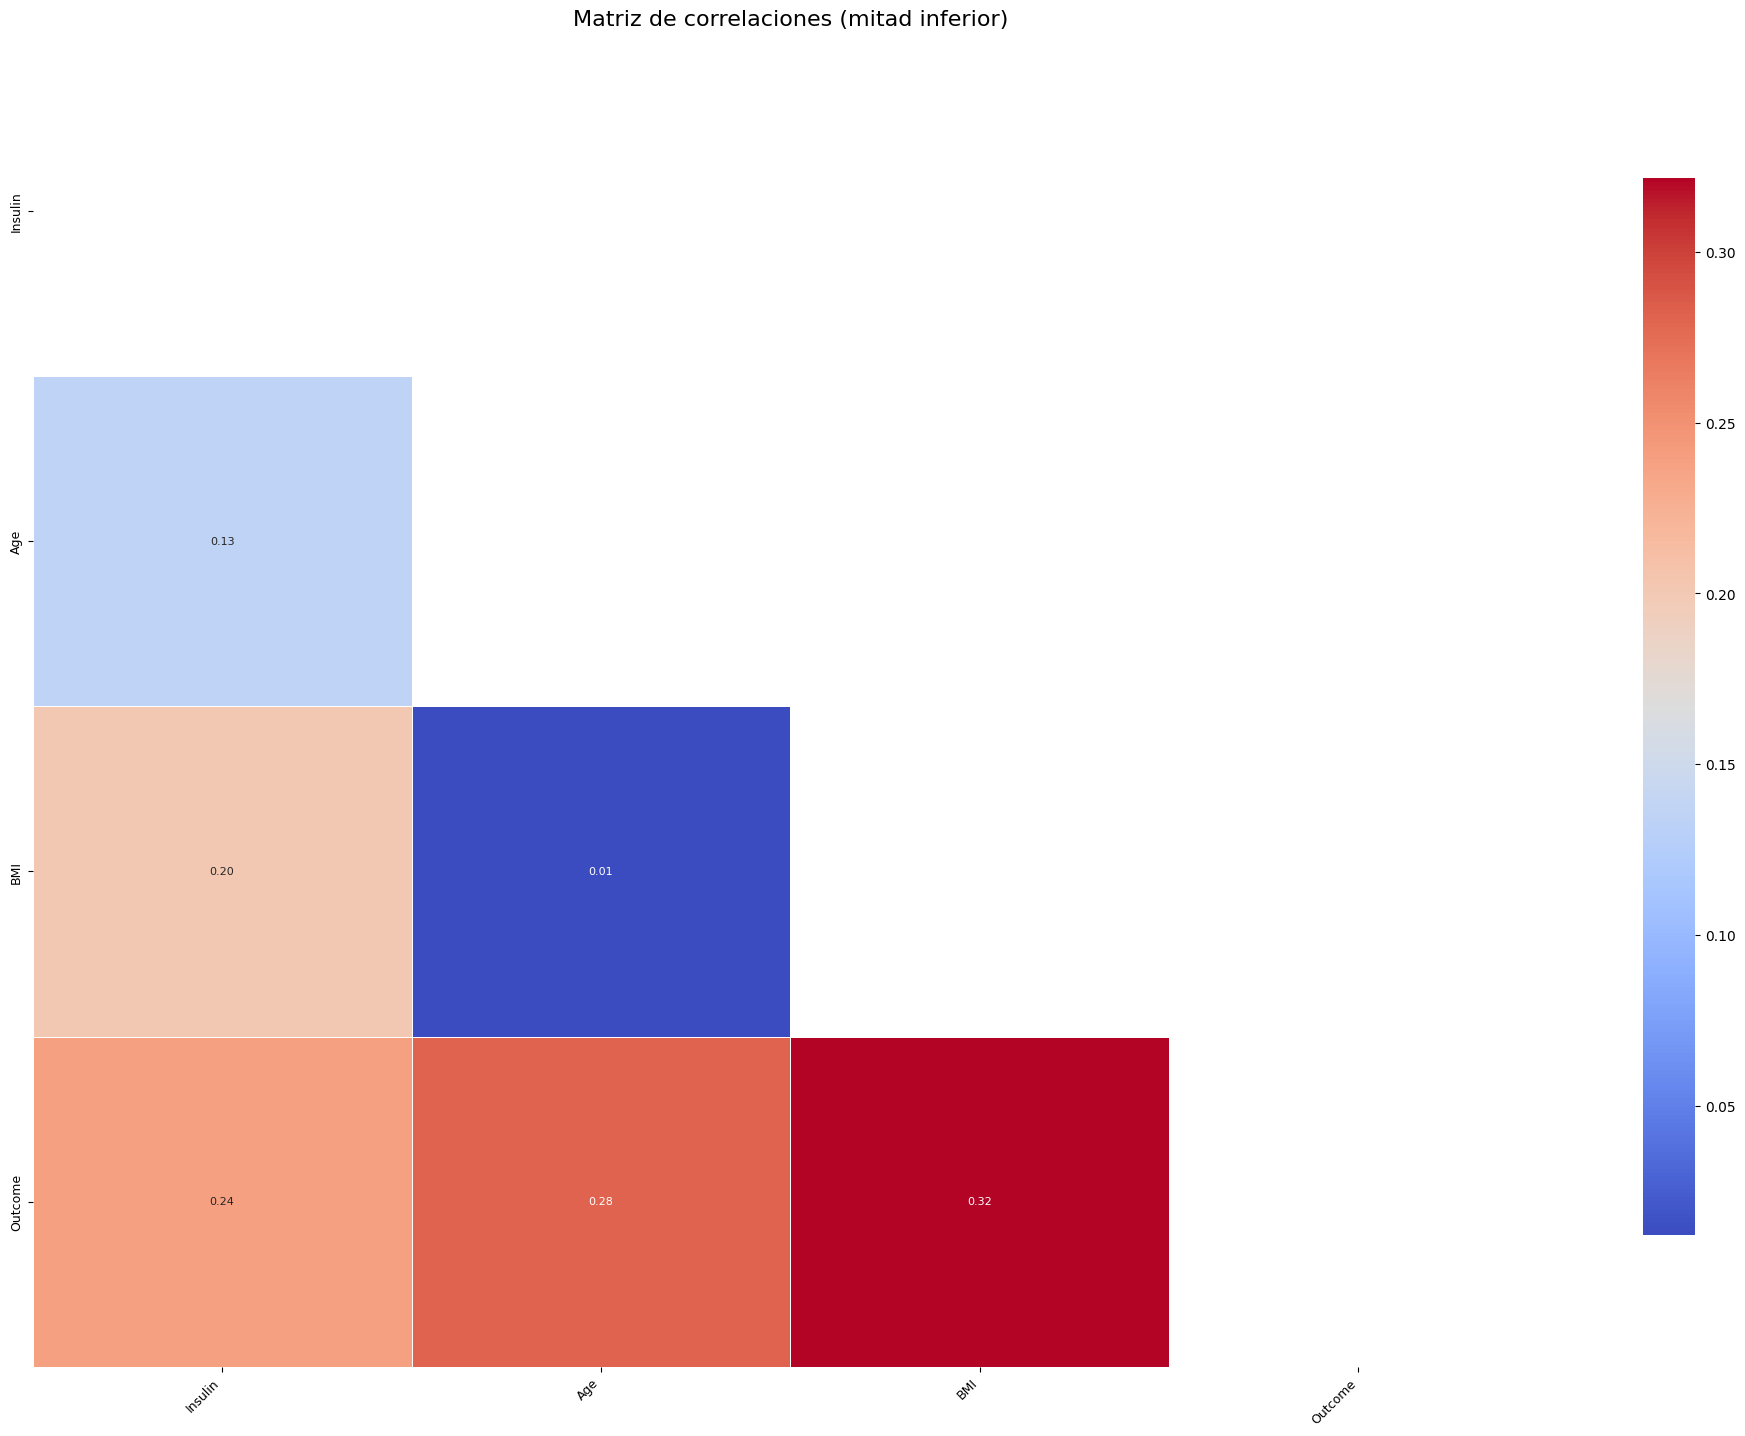

In [41]:
X_copy = X_train_imp[features].copy()
X_copy['Outcome'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Cross validation

In [42]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1, class_weight='balanced'),X_train_imp[features], y_train, cv=3, scoring='recall')

In [43]:
cv_results1.mean()

np.float64(0.488262910798122)

In [44]:
#V2

cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1,class_weight='balanced'),X_train_imp,y_train,cv=3,scoring='recall')
print(cv_results2)

[0.66197183 0.66197183 0.5915493 ]


In [45]:
cv_results2.mean()

np.float64(0.6384976525821596)

Modelado

In [46]:
X_train_sel = X_train_imp
X_test_sel = X_test_imp

In [47]:
#Modelo 1: criterio GINI
tree1 = DecisionTreeClassifier(criterion='gini',max_depth=None, max_features=X_train_sel.shape[1]//2, min_samples_leaf=1,random_state=42)

tree1.fit(X_train_sel, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
#evaluacion del modelo en entrenamiento y prueba
train_pred_tree1 = tree1.predict(X_train_sel)
test_pred_tree1 = tree1.predict(X_test_sel)

In [49]:
def get_metrics(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_auc = train_auc - test_auc
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy, train_f1, train_auc, train_precision, train_recall, train_specificity],[test_accuracy, test_f1, test_auc, test_precision, test_recall, test_specificity],[diff_accuracy, diff_f1, diff_auc, diff_precision, diff_recall, diff_specificity]],
                              columns = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall', 'Specificity'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

In [50]:
get_metrics(y_train,y_test,train_pred_tree1,test_pred_tree1)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,1.00,1.00,1.00,1.00,1.00,1.00
Test,0.74,0.62,0.71,0.65,0.58,0.83
Diferencia,0.26,0.38,0.29,0.35,0.42,0.17


In [51]:
#Matriz de confusion tree1
cm = confusion_matrix(y_test, test_pred_tree1)
cm

array([[82, 17],
       [23, 32]])

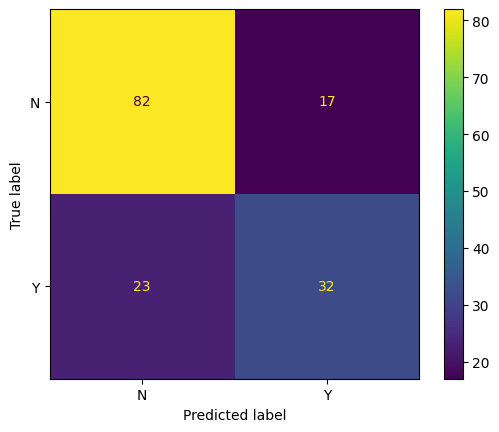

In [52]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

In [53]:
#Modelo 2: ENTROPY
tree2 = DecisionTreeClassifier(criterion='entropy',max_depth=None, max_features=X_train_sel.shape[1]//2, min_samples_leaf=1,random_state=42)

tree2.fit(X_train_sel, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,4
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
#evaluacion del modelo en entrenamiento y prueba
train_pred_tree2 = tree2.predict(X_train_sel)
test_pred_tree2 = tree2.predict(X_test_sel)

In [55]:
get_metrics(y_train,y_test,train_pred_tree2,test_pred_tree2)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,1.00,1.00,1.00,1.00,1.00,1.00
Test,0.74,0.64,0.72,0.64,0.64,0.80
Diferencia,0.26,0.36,0.28,0.36,0.36,0.20


In [56]:
#matriz de confusion Tree2
cm = confusion_matrix(y_test, test_pred_tree2)
cm

array([[79, 20],
       [20, 35]])

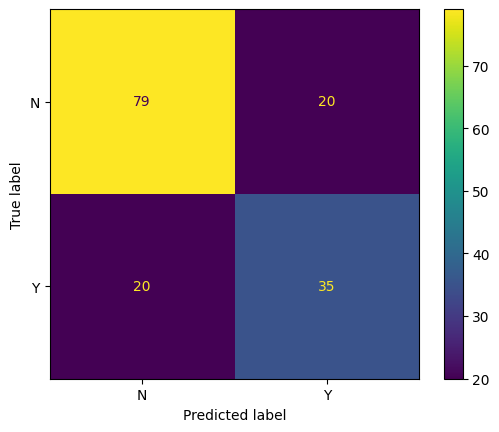

In [57]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

en este caso seleccionaré el criterio Entropy para la implementación final, ya que el Recall con criterio Gini es de 58% mientras que con entropy es de 64%. Lo que quiere decir que con criterio entropy tenemos una mayor probabilidad de capturar los casos reales de diabetes. 

Optimización de hiper parámetros

In [58]:
#B. Intensiva
model = DecisionTreeClassifier()

param_grid = {'criterion': ['entropy'],
              'max_depth': [3, 4, 5, 6, 8, None],
              'min_samples_leaf': [5, 10, 15, 20, 25],
              'max_features': [None, 'sqrt', 'log2', 0.5],
              'min_samples_split': [2, 5, 10, 20]}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ajuste
grid_search.fit(X_train_sel, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=2; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=entropy, max_depth=3, max_features=None, min_samples_leaf=5, min_samples_spli

In [59]:
train_pred_best = best_model.predict(X_train_sel)
test_pred_best = best_model.predict(X_test_sel)


In [60]:
get_metrics(y_train, y_test, train_pred_best, test_pred_best)

,Accuracy,F1,AUC,Precision,Recall,Specificity
Train,0.82,0.75,0.82,0.71,0.80,0.83
Test,0.73,0.67,0.74,0.59,0.76,0.71
Diferencia,0.09,0.09,0.08,0.12,0.04,0.12


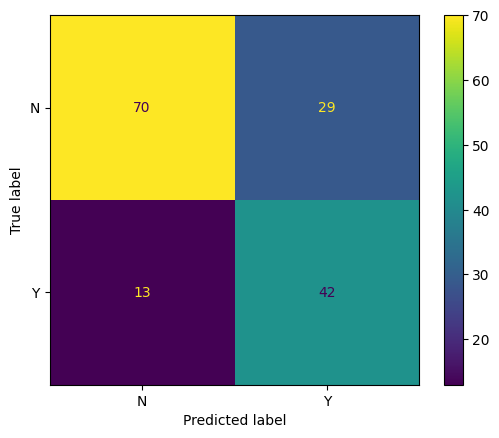

In [61]:
cm = confusion_matrix(y_test, test_pred_best)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'Y'])
disp.plot()

Export. del modelo

In [62]:
joblib.dump(best_model, 'modelo_diabetes.pkl')

['modelo_diabetes.pkl']